<a href="https://colab.research.google.com/github/ia-p16/tslearn-workshop-2026/blob/main/workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TSlearn workshop
================

This workshop showcases the `tslearn` library for time-series machine learning using *a multi-sensor activities-of-daily-living* dataset. It is designed to be hands-on and compact so you can quickly experiment with preprocessing, clustering and classification techniques for time series.

Goals
- Learn common preprocessing steps (imputation, resampling, scaling).
- Explore time-series clustering and classification techniques (DTW, KNN, Shapelets).
- Visualize and evaluate models using the provided utilities.

Prerequisites
- Python 3.8+ and pip; basic familiarity with numpy and scikit-learn.
- Optional: Google Colab (badge above) for easy environment setup.


Dataset description https://data.mendeley.com/datasets/wjpbtgdyzm/2

TSlearn documentation: https://tslearn.readthedocs.io/en/latest/

## Setup

In [ ]:
%%capture
%pip install --extra-index-url https://download.pytorch.org/whl/cpu 'tslearn[all_features] @ https://github.com/tslearn-team/tslearn/archive/main.zip'


import sys
colab = 'google.colab' in sys.modules
if colab:
    import google.colab
    print(f"Google Colab Version: {google.colab.__version__}")
    
    !git clone https://github.com/ia-p16/tslearn-workshop-2026.git
    import os
    os.chdir("tslearn-workshop-2026")      

## Dataset 

The dataset contains multiple instances of :

- 9 Activities of Daily Living (ADL): 

    Walk, Sit Down, Stand Up, Open Door, Close Door, Pour Water, Drink Glass, Brush Teeth and Clean Table

- 10 volunteers performed each activity at least 14 times; walking activity that has been performed 40 times

- each volunteers wore 6 inertial measurement units (IMU) sensors on 6 body parts:

    left lower arm (lla), left upper arm, (lua), right lower arm (rla), right upper arm (rua) and right thigh (rt).

- each IMU takes 6 measurements by accelerometer (x, y, z) and gyroscope (x, y, x) 


The [utils.py](utils.py) module available for this workshop, provides functions for data retrieval and visualization.
`get_X_y` is notably used to retrieve data for:
- specified volunteer(s) `[1:10]` 
- with IMUs being sequenced as `["back", "lla", "lua", "rla", "rt", "rua"]`.
- Available features are `["x-acc", "y-acc", "z-acc", "x-vel", "y-vel", "z-vel"]`.
- for tasks `["walk", "sitdown", "standup", "opendoor", "closedoor", "pourwater", "drinkglass", "brushteeth", "cleantable"]`.
- returns 3 dimensional array of time series per activity(task), with time as 2nd dimension and sensor readings as 3rd. 

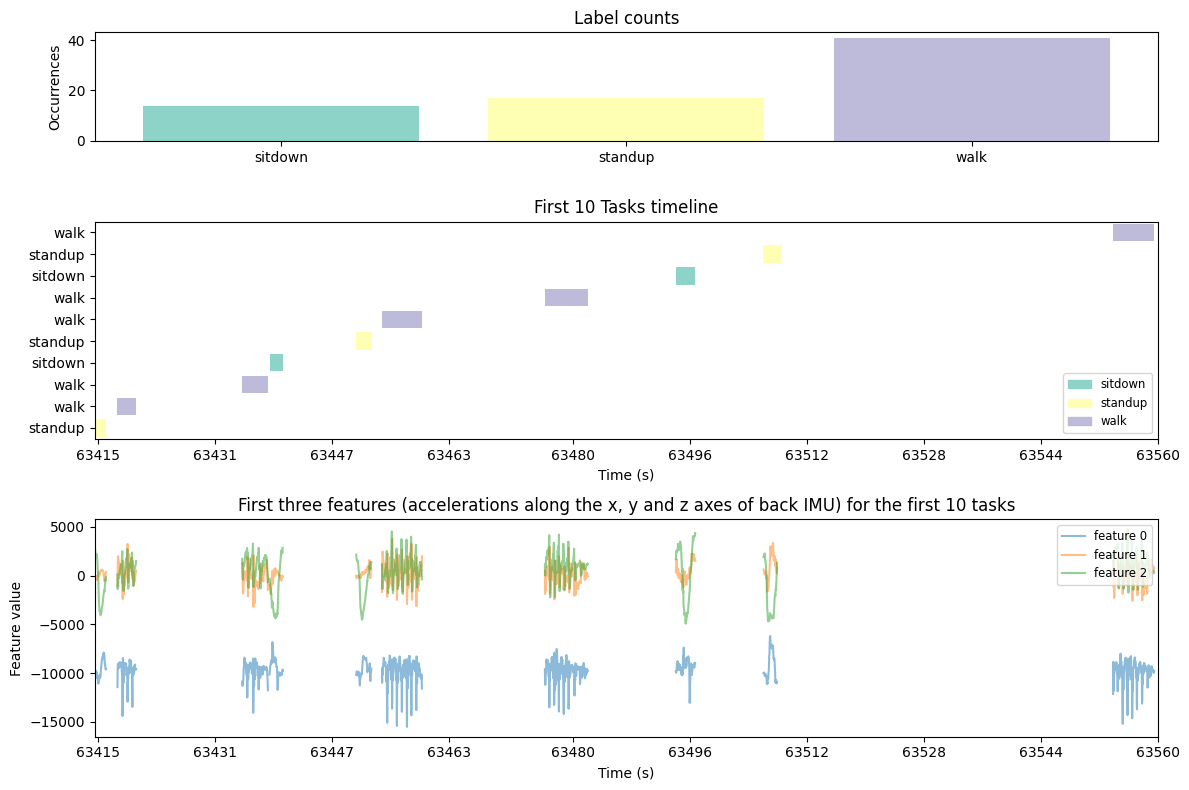

In [2]:
from utils import get_X_y, visualize_dataset_overview
import numpy as np

dataset, tasks = get_X_y(volunteers=[1], task_labels=["sitdown", "standup", "walk"], features=["x-acc", "y-acc", "z-acc"])
labels = np.array(tasks)[:, 2]
visualize_dataset_overview(labels, tasks, dataset)

## Preprocessing

In [16]:
dataset, tasks = get_X_y()
labels = np.array(tasks)[:, 2]
dataset.shape, labels.shape

((1839, 319, 36), (1839,))

💡 Take some time to figure out / remember what the dataset shape represents...

### Impute

Imputing missing values in time series preserves temporal continuity. `tslearn` implements a few methods of imputing time series values, including mean, median, ffill, bfill, linear, constant, or you can provide a custom method.

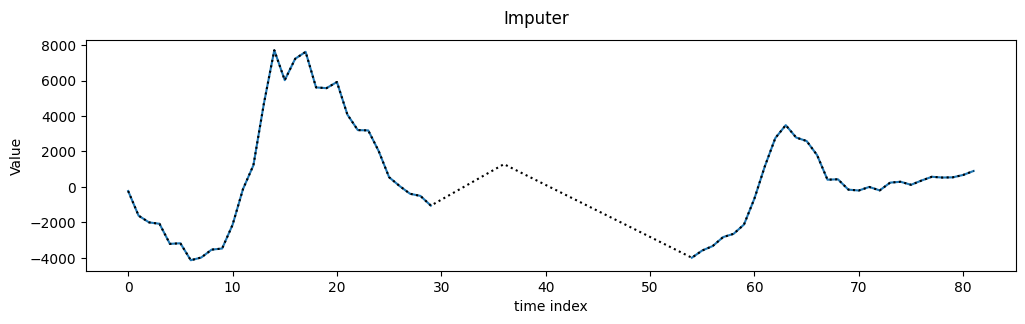

In [17]:
# Imputer: this particular time series has missing data 
# corresponding to the lla imu (feature 6 to 11)
task = 1081
feature = 10

from tslearn.preprocessing import TimeSeriesImputer
imputed = TimeSeriesImputer(method="linear", keep_trailing_nans=True).fit_transform(dataset[task, :, feature].reshape(1, -1))

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 3))
fig.suptitle('Imputer')
plt.plot(dataset[task, :, feature])
plt.plot(imputed.reshape(-1), 'k:')
plt.ylabel("Value")
plt.xlabel("time index")
plt.show()

💡 Take some time to play with the TimeSeriesImputer parameters

### Resample

Resampling enforces a common temporal length across time series, enabling consistent preprocessing and distance computations.  By default, the size of the longest time series of dataset is used. If the target size is specified then the `tslearn` imputer either upsamples or downsamples the timeseries.   

In [19]:
from tslearn.preprocessing import TimeSeriesResampler
from tslearn.utils import ts_size

resampled_dataset = TimeSeriesResampler(sz=300).fit_transform(dataset)
ts_size(dataset[0]), ts_size(resampled_dataset[0]), dataset.shape[1], resampled_dataset.shape[1]

(106, 300, 319, 300)

In [23]:
dataset.shape

(1839, 319, 36)

### Scale

Scaling ensures feature magnitudes are comparable so no single sensor or axis dominates distance computations or model training. Choose `tslearn`'s *mean–variance* or *min–max* scaling, and control the scope with *per timeseries* (compute stats per series), *per feature* (compute stats per feature across all series), or set both False to compute statistics globally across the entire dataset.

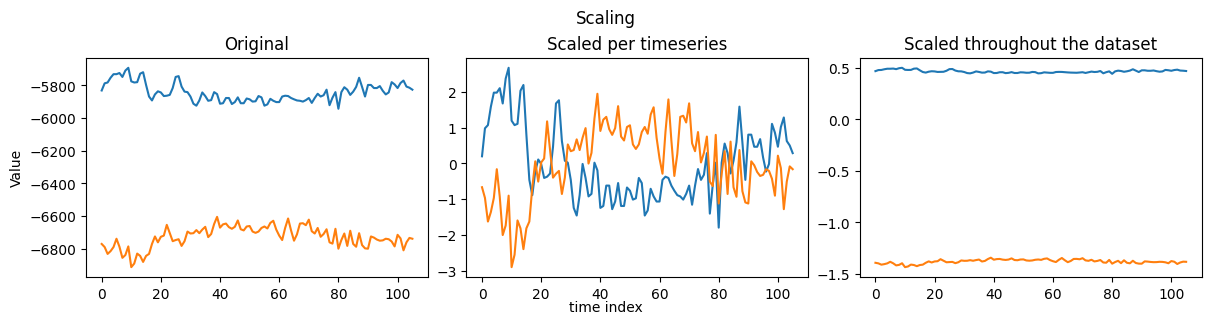

In [35]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
per_ts = TimeSeriesScalerMeanVariance(per_timeseries=True, per_feature=True).fit_transform(dataset[:,:, 6:8])
all_ts = TimeSeriesScalerMeanVariance(per_timeseries=False, per_feature=True).fit_transform(dataset[:,:,6:8])

fig, axs = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
fig.suptitle('Scaling')
fig.text(0.5, -0.02, 'time index', ha='center')
ax = axs[0]
ax.set_ylabel("Value")
ax.plot(dataset[0, :, 6])
ax.plot(dataset[0, :, 7])
ax.set_title('Original')
ax = axs[1]
ax.plot(per_ts[0, :, 0])
ax.plot(per_ts[0, :, 1])
ax.set_title('Scaled per timeseries')
ax = axs[2]
ax.plot(all_ts[0, :, 0])
ax.plot(all_ts[0, :, 1])
ax.set_title('Scaled throughout the dataset')
plt.show()

## Clustering

Clustering groups similar time-series instances to discover patterns or behaviors without labels; for time series this typically means using sequence-aware distances (e.g., DTW (dynamic time warping)). 

In [36]:
task_labels = ["walk", "standup", "sitdown"]
volunteers =  [1]
imus = None
features = ["x-acc", "y-acc", "z-acc"]

n_clusters = len(task_labels)

dataset, tasks = get_X_y(volunteers=volunteers, imus=imus, features=features, task_labels=task_labels)
labels = np.array(tasks)[:, 2]
print(dataset.shape, [f"{task_label}: {np.count_nonzero(labels == task_label)}" for task_label in task_labels])

(72, 226, 18) ['walk: 41', 'standup: 17', 'sitdown: 14']


### sklearn KMEANS

To establish a base model, let's convert series to fixed‑length representations and apply standard non‑time‑series clustering method.

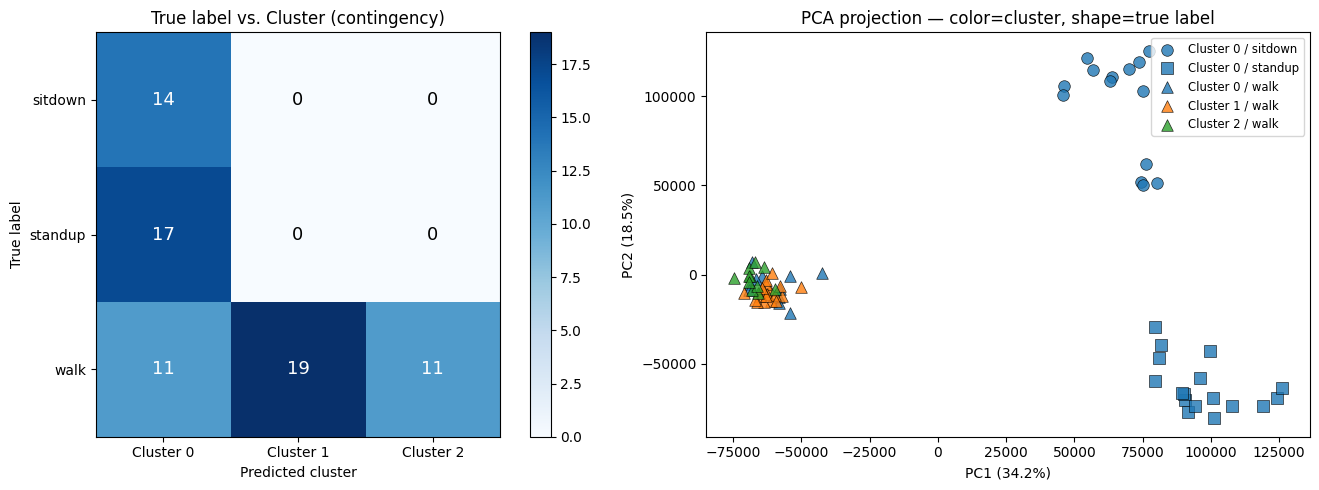

In [40]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing  import StandardScaler
from sklearn.cluster import KMeans

from tslearn.utils import to_sklearn_dataset

from utils import visualize_clustering_results

sk_dataset = to_sklearn_dataset(dataset)
sk_dataset = SimpleImputer(strategy="constant", fill_value =0.0).fit_transform(sk_dataset)
sk_dataset = StandardScaler().fit_transform(sk_dataset)
cl_sk_kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(sk_dataset)

visualize_clustering_results(cl_sk_kmeans, dataset, labels)

### tslearn KMEANS with DTW metric

Now run KMeans using tslearn's time‑series‑aware implementation so clustering groups series by their temporal patterns rather than by point-wise, flattened similarity. YOu can use the same visualization function `visualize_clustering_results` to compare the results. 

In [ ]:
# perform KMEANS clustering using tslearn and visualize results
from tslearn.clustering import TimeSeriesKMeans

# Write your code here

visualize_clustering_results(..., dataset, labels)

💡 Reflect on the difference in the results between point-wise and temporal models.

In [ ]:
# You might want to take a look at the computed attributes after clustering is performed and 
# plot the cluster centroids to see the patterns that were learned by the model.
from utils import visualize_cluster_centroids

# Write your code here 

visualize_cluster_centroids(..., features)

The *silhouette score* measures how well each series fits its assigned cluster compared with other clusters by combining cohesion (intra‑cluster distance) and separation (nearest‑cluster distance) into a single value in [-1, 1], where values near +1 indicate well‑separated, compact clusters and values near or below 0 indicate overlapping or misassigned points.  

Use it to compare clustering algorithms or hyperparameters (e.g., number of clusters, DTW vs. Euclidean) and to get a quick, interpretable quality metric; note it requires pairwise distances (so using DTW can be computationally expensive).

In [ ]:
from sklearn.metrics import silhouette_score

#Write your code here

💡 Reflect on how well the cluster patterns are learned.

## Classification

In [43]:
task_labels = ["sitdown", "drinkglass", "walk", "opendoor", "cleantable", "brushteeth"]
volunteers =  [1]
imus = ["back"]
features = ["z-acc"]
n_classes = len(task_labels)

dataset, tasks = get_X_y(volunteers=volunteers, imus=imus, features=features, task_labels=task_labels)
labels = np.array(tasks)[:, 2]
print(dataset.shape, [f"{task_label}: {np.count_nonzero(labels == task_label)}" for task_label in task_labels])

(129, 272, 1) ['sitdown: 14', 'drinkglass: 24', 'walk: 41', 'opendoor: 17', 'cleantable: 18', 'brushteeth: 15']


In [44]:
# split the dataset while preserving the label distribution (stratification) and shuffling the data
from sklearn.model_selection import train_test_split

from tslearn.preprocessing import TimeSeriesScalerMeanVariance

dataset = TimeSeriesScalerMeanVariance().fit_transform(dataset)

train_data, test_data, train_labels, test_labels = train_test_split(
    dataset, labels, test_size=0.3, random_state=0, stratify=labels, shuffle=True
)
for x in np.unique(labels):
    print(x, 
          "train", len(np.argwhere(train_labels==x)), 
          "test", len(np.argwhere(test_labels==x)), 
          "total", len(np.argwhere(labels==x)),
          "test%", np.round((len(np.argwhere(test_labels==x)) / len(np.argwhere(labels==x))), 2) if len(np.argwhere(labels==x)) > 0 else 0.0)

brushteeth train 10 test 5 total 15 test% 0.33
cleantable train 12 test 6 total 18 test% 0.33
drinkglass train 17 test 7 total 24 test% 0.29
opendoor train 12 test 5 total 17 test% 0.29
sitdown train 10 test 4 total 14 test% 0.29
walk train 29 test 12 total 41 test% 0.29


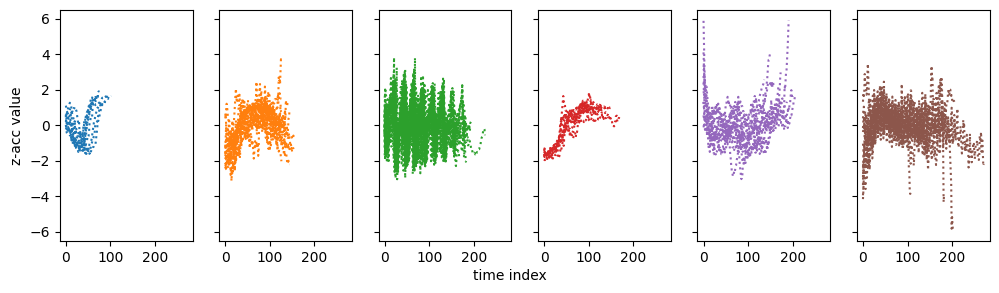

In [45]:
# Visualize data
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, n_classes, figsize=(12, 3), sharex=True, sharey=True)
axs[0].set_ylabel('z-acc value')
fig.text(0.5, -0.02, 'time index', ha='center')
colors = plt.get_cmap("tab10").colors

for i in range(n_classes):
    for x in train_data[train_labels==task_labels[i]]:
        for imu_index in range(len(imus)):
            for feature_index in range(len(features)):
                axs[i].plot(x[..., feature_index + imu_index * 3], linestyle=":", color=colors[i])

### KNN example

#### sklearn KNN

In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

from tslearn.preprocessing import TimeSeriesResampler
from tslearn.utils import to_sklearn_dataset

equal_size_train_data = TimeSeriesResampler().fit_transform(train_data)
sk_train_data = to_sklearn_dataset(equal_size_train_data)

sk_knn = KNeighborsClassifier()
parameters = {'n_neighbors': list(range(1, 6))}
sk_grid = GridSearchCV(sk_knn, parameters).fit(sk_train_data, train_labels)

mean_scores = np.array(sk_grid.cv_results_["mean_test_score"])
print(mean_scores)

[0.72222222 0.71111111 0.75555556 0.74444444 0.75555556]


In [47]:
equal_size_test_data = TimeSeriesResampler(equal_size_train_data.shape[1]).fit_transform(test_data)
sklearn_test_data = to_sklearn_dataset(equal_size_test_data)
y_pred_euclidean = sk_grid.predict(sklearn_test_data)

visualize_classification_results(sk_grid, test_labels, y_pred_euclidean)

NameError: name 'visualize_classification_results' is not defined

### tslearn KNN with DTW metric

In [ ]:
# Perform KNN classification using tslearn and visualize results
# You might want to take a look at the computed attributes after
# classification is performed

### Shapelets model

In [ ]:
task_labels = ["standup", "sitdown"]
volunteers =  [1, 2, 3, 4, 8, 9, 10]
n_classes = len(task_labels)
imus = ["rt"]
features = ["x-acc"]

dataset, tasks = get_X_y(volunteers=volunteers, imus=imus, features=features, task_labels=task_labels, min_size=30)
labels = np.array(tasks)[:, 2]
print(dataset.shape, [f"{task_label}: {np.count_nonzero(labels == task_label)}" for task_label in task_labels])

In [ ]:
# Visualize data
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, n_classes, figsize=(12, 3))
fig.text(0.5, -0.02, 'time index', ha='center')
axs[0].set_ylabel('x-acc value')
colors = plt.get_cmap("tab10").colors

for i in range(n_classes):
    for x in dataset[labels==task_labels[i]]:
        for imu_index in range(len(imus)):
            for feature_index in range(len(features)):
                axs[i].set_title(task_labels[i])
                axs[i].plot(x[..., feature_index + imu_index * len(features)], linestyle=':', color=colors[feature_index])

In [ ]:
from sklearn.model_selection import train_test_split
train_data, test_data, train_labels, test_labels = train_test_split(
    dataset, labels, test_size=0.3, random_state=0, stratify=labels, shuffle=True
)
for x in np.unique(labels):
    print(x, 
          "train", len(np.argwhere(train_labels==x)), 
          "test", len(np.argwhere(test_labels==x)), 
          "total", len(np.argwhere(labels==x)),
          "test%", np.round((len(np.argwhere(test_labels==x)) / len(np.argwhere(labels==x))), 2) if len(np.argwhere(labels==x)) > 0 else 0.0)


In [ ]:
from tslearn.shapelets import LearningShapelets

from utils import visualize_classification_results

shapelet_clf = LearningShapelets(
    n_shapelets_per_size={30: 2},
    scale=True,
    random_state=0, 
    max_iter=500,
    batch_size=16, 
    optimizer="adam"
).fit(train_data, train_labels)

y_pred_shapelets = shapelet_clf.predict(test_data)

In [ ]:
visualize_classification_results(shapelet_clf, test_labels, y_pred_shapelets)

In [ ]:
# visualize learned shapelets (one plot per shapelet, all features in each plot)
from utils import visualize_shapelets

visualize_shapelets(shapelet_clf, feature_names=features)

In [ ]:
from tslearn.preprocessing import TimeSeriesScalerMinMax

from utils import visualize_shapelet_matches

visualize_shapelet_matches(shapelet_clf, TimeSeriesScalerMinMax().fit_transform(train_data), train_labels, show_feature=0)

### Large scale shapelets

In [ ]:
# Given the following dataset, perform classification using the shapelet models 

task_labels = ["walk", "standup", "sitdown"]
volunteers =  None
imus = ["back"]
features = None
n_classes = len(task_labels)

dataset, tasks = get_X_y(volunteers=volunteers, imus=imus, features=features, task_labels=task_labels, min_size=30)
labels = np.array(tasks)[:, 2]
train_data, test_data, train_labels, test_labels = train_test_split(
    dataset, labels, test_size=0.3, random_state=0, stratify=labels, shuffle=True
)